<a href="https://colab.research.google.com/github/Naseeha-O/Banknote-Classification-Project/blob/main/Main_pipeline_702_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Caitlin Fogg 223005053
# Tarika Sukdeoa 223010024
# Naseeha Osman 223005931

In [ ]:
#Imports
import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shutil
from glob import glob

from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set your paths
RAW_IMAGES_FOLDER = "/content/drive/MyDrive/raw_images"      # Where your raw images are
OUTPUT_FOLDER = "/content/drive/MyDrive/banknote_dataset"    # Where to save the dataset

In [ ]:
# Configurations
extensions = ['*.jpg', '*.jpeg', '*.JPG', '*.JPEG', '*.png', '*.PNG']
CLASSES = ['R10', 'R20', 'R50', 'R100', 'R200']

class_to_label = {c: i for i, c in enumerate(CLASSES)}
label_to_class = {i: c for i, c in enumerate(CLASSES)}

print(f"Total classes: {len(CLASSES)}")
print("\nClass mapping:")
for i, c in enumerate(CLASSES):
    print(f"  {i}: {c}")

Total classes: 5

Class mapping:
  0: R10
  1: R20
  2: R50
  3: R100
  4: R200


In [ ]:
# ------ Preprocessing Functions -------
def resize_image(img, target_width=800):
    h, w = img.shape[:2]

    # Fix portrait orientation
    if h > w:
        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        h, w = img.shape[:2]

    # Preserve aspect ratio
    aspect_ratio = w / h
    target_height = int(target_width / aspect_ratio)

    resized = cv2.resize(
        img,
        (target_width, target_height),
        interpolation=cv2.INTER_AREA
    )

    return resized

def to_gray(img):
    if len(img.shape) == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

# Noise reduction methods (for comparison)
def apply_gaussian(img):
  return cv2.GaussianBlur(img, (5,5), 0)

def apply_median(img):
  return cv2.medianBlur(img, 5)

def apply_bilateral(img):
  return cv2.bilateralFilter(img, 9, 75, 75)

# Contrast enhancement methods (for comparison)
def apply_equalization(img):
  return cv2.equalizeHist(img)

def apply_CLAHE(img):
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
  return clahe.apply(img)

def preprocess_image(img):
    # 1. Resize + orientation fix
    img = resize_image(img)

    # 2. grayscale
    img = to_gray(img)

    # 3. noise reduction comparison (baseline - gaussian)
    img = apply_gaussian(img)
    #img = apply_median(img)
    #img = apply_bilateral(img)

    # 4. contrast enhancement comparison (baseline - histogram equalization)
    img = apply_equalization(img)
    #img = apply_CLAHE(img)

    return img

In [ ]:
# ------ Segmentation Functions --------

import cv2
import numpy as np
import matplotlib.pyplot as plt



# ============================================================================
# METHOD 1: BASELINE (Your original method)
# ============================================================================

def get_biggest_contour_baseline(image):
    """Original baseline method using Canny + morphological gradient"""
    if len(image.shape) == 2:
        grey = image
        colour = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        colour = image.copy()

    edges = cv2.Canny(grey, 30, 100)

    kernel = np.ones((3,3), np.uint8)
    gradient = cv2.morphologyEx(edges, cv2.MORPH_GRADIENT, kernel)
    _, gradient_thresh = cv2.threshold(gradient, 30, 255, cv2.THRESH_BINARY)

    combined = cv2.bitwise_or(edges, gradient_thresh)

    dilate_image = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel, iterations=2)
    dilate_image = cv2.morphologyEx(dilate_image, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(dilate_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    valid = []
    img_area = grey.shape[0] * grey.shape[1]

    for c in contours:
        area = cv2.contourArea(c)
        if area / img_area > 0.05:
            valid.append(c)

    if not valid:
        return None

    biggest = max(valid, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(biggest, True)
    approx = cv2.approxPolyDP(biggest, epsilon, True)

    return approx


# ============================================================================
# METHOD 2: SOBEL EDGE DETECTION (Replaces Canny)
# ============================================================================

def get_biggest_contour_sobel(image):
    """Alternative: Use Sobel edge detection instead of Canny"""
    if len(image.shape) == 2:
        grey = image
    else:
        grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Sobel edge detection
    sobel_x = cv2.Sobel(grey, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(grey, cv2.CV_64F, 0, 1, ksize=3)
    edges = cv2.magnitude(sobel_x, sobel_y)
    edges = np.uint8(np.clip(edges, 0, 255))

    # Threshold to get binary edges
    _, edges = cv2.threshold(edges, 30, 255, cv2.THRESH_BINARY)

    kernel = np.ones((3,3), np.uint8)
    dilate_image = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)
    dilate_image = cv2.morphologyEx(dilate_image, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(dilate_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    valid = []
    img_area = grey.shape[0] * grey.shape[1]

    for c in contours:
        area = cv2.contourArea(c)
        if area / img_area > 0.05:
            valid.append(c)

    if not valid:
        return None

    biggest = max(valid, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(biggest, True)
    approx = cv2.approxPolyDP(biggest, epsilon, True)

    return approx


# ============================================================================
# METHOD 3: ADAPTIVE THRESHOLDING ONLY (No edge detection)
# ============================================================================

def get_biggest_contour_adaptive(image):
    """Alternative: Use adaptive thresholding, find largest blob"""
    if len(image.shape) == 2:
        grey = image
    else:
        grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(grey, (5,5), 0)

    # Adaptive thresholding
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 2)

    # Morphological operations to clean
    kernel = np.ones((5,5), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel, iterations=1)

    # Find contours
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # Filter by area
    valid = []
    img_area = grey.shape[0] * grey.shape[1]

    for c in contours:
        area = cv2.contourArea(c)
        if area / img_area > 0.05:
            valid.append(c)

    if not valid:
        return None

    biggest = max(valid, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(biggest, True)
    approx = cv2.approxPolyDP(biggest, epsilon, True)

    return approx


# ============================================================================
# METHOD 4: OTSU THRESHOLDING + LARGEST BLOB
# ============================================================================

def get_biggest_contour_otsu(image):
    """Alternative: Simple Otsu thresholding, then largest connected component"""
    if len(image.shape) == 2:
        grey = image
    else:
        grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Gaussian blur
    blurred = cv2.GaussianBlur(grey, (5,5), 0)

    # Otsu thresholding
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morphological closing to fill gaps
    kernel = np.ones((5,5), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Find contours
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # Take largest contour
    biggest = max(contours, key=cv2.contourArea)

    # Approximate to quadrilateral
    epsilon = 0.02 * cv2.arcLength(biggest, True)
    approx = cv2.approxPolyDP(biggest, epsilon, True)

    return approx


# ============================================================================
# METHOD 5: WATERSHED SEGMENTATION
# ============================================================================

def get_biggest_contour_watershed(image):
    """Alternative: Use watershed algorithm to segment banknote"""
    if len(image.shape) == 2:
        grey = image
        colour = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        colour = image.copy()

    # Threshold
    _, thresh = cv2.threshold(grey, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Noise removal
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # Sure background
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # Sure foreground (distance transform)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    # Unknown region
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Markers
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    # Apply watershed
    markers = cv2.watershed(colour, markers)

    # Find the note region (largest segment)
    note_mask = (markers == 2).astype(np.uint8) * 255

    contours, _ = cv2.findContours(note_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    biggest = max(contours, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(biggest, True)
    approx = cv2.approxPolyDP(biggest, epsilon, True)

    return approx


# ============================================================================
# METHOD 6: K-MEANS CLUSTERING SEGMENTATION
# ============================================================================

def get_biggest_contour_kmeans(image, k=2):
    """Alternative: Use K-means clustering to separate note from background"""
    if len(image.shape) == 2:
        # Convert grayscale to 3-channel for K-means
        colour = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        colour = image.copy()

    # Reshape to 1D array of pixels
    pixels = colour.reshape(-1, 3)
    pixels = np.float32(pixels)

    # K-means clustering (k=2: background and note)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    _, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    # Reshape labels back to image shape
    labels = labels.reshape(colour.shape[:2])

    # Find which cluster is the note (largest area)
    unique, counts = np.unique(labels, return_counts=True)
    note_cluster = unique[np.argmax(counts)]

    # Create mask for note
    mask = (labels == note_cluster).astype(np.uint8) * 255

    # Clean mask
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    biggest = max(contours, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(biggest, True)
    approx = cv2.approxPolyDP(biggest, epsilon, True)

    return approx


# ============================================================================
# METHOD 7: FLOOD FILL (REGION GROWING)
# ============================================================================

def get_biggest_contour_floodfill(image, seed_percent=(0.5, 0.5)):
    """Alternative: Use flood fill starting from image center"""
    if len(image.shape) == 2:
        grey = image
    else:
        grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Get image dimensions
    h, w = grey.shape

    # Seed point (default: center of image)
    seed_x = int(w * seed_percent[0])
    seed_y = int(h * seed_percent[1])

    # Create mask (floodFill needs extra border)
    mask = np.zeros((h+2, w+2), dtype=np.uint8)

    # Apply flood fill
    lo_diff = 30
    up_diff = 30
    cv2.floodFill(grey, mask, (seed_x, seed_y), 255,
                  lo_diff, up_diff, cv2.FLOODFILL_FIXED_RANGE)

    # Extract filled region
    filled = mask[1:h+1, 1:w+1]

    # Find contours
    contours, _ = cv2.findContours(filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    biggest = max(contours, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(biggest, True)
    approx = cv2.approxPolyDP(biggest, epsilon, True)

    return approx


# ============================================================================
# METHOD 8: GRABCUT SEGMENTATION (Rectangle initialization)
# ============================================================================

def get_biggest_contour_grabcut(image):
    """Alternative: Use GrabCut algorithm with automatic rectangle"""
    if len(image.shape) == 2:
        colour = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        colour = image.copy()

    h, w = colour.shape[:2]

    # Define rectangle around image (assuming note is centered)
    rect = (int(w*0.1), int(h*0.1), int(w*0.8), int(h*0.8))

    # Initialize mask
    mask = np.zeros(colour.shape[:2], np.uint8)

    # Apply GrabCut
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    cv2.grabCut(colour, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

    # Create mask for likely foreground
    mask2 = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 255, 0).astype(np.uint8)

    # Find contours
    contours, _ = cv2.findContours(mask2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    biggest = max(contours, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(biggest, True)
    approx = cv2.approxPolyDP(biggest, epsilon, True)

    return approx


# ============================================================================
# METHOD 9: EDGE DETECTION WITH DIFFERENT CANNY THRESHOLDS
# ============================================================================

def get_biggest_contour_canny_variant(image, low_threshold=50, high_threshold=150):
    """Alternative: Same as baseline but with adjustable Canny thresholds"""
    if len(image.shape) == 2:
        grey = image
        colour = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        colour = image.copy()

    edges = cv2.Canny(grey, low_threshold, high_threshold)

    kernel = np.ones((3,3), np.uint8)
    gradient = cv2.morphologyEx(edges, cv2.MORPH_GRADIENT, kernel)
    _, gradient_thresh = cv2.threshold(gradient, 30, 255, cv2.THRESH_BINARY)

    combined = cv2.bitwise_or(edges, gradient_thresh)

    dilate_image = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel, iterations=2)
    dilate_image = cv2.morphologyEx(dilate_image, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(dilate_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    valid = []
    img_area = grey.shape[0] * grey.shape[1]

    for c in contours:
        area = cv2.contourArea(c)
        if area / img_area > 0.05:
            valid.append(c)

    if not valid:
        return None

    biggest = max(valid, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(biggest, True)
    approx = cv2.approxPolyDP(biggest, epsilon, True)

    return approx


# ============================================================================
# METHOD 10: MORPHOLOGICAL OPERATIONS WITH LARGER KERNEL
# ============================================================================

def get_biggest_contour_large_kernel(image, kernel_size=5):
    """Alternative: Same as baseline but with larger morphological kernel"""
    if len(image.shape) == 2:
        grey = image
        colour = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        colour = image.copy()

    edges = cv2.Canny(grey, 30, 100)

    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    gradient = cv2.morphologyEx(edges, cv2.MORPH_GRADIENT, kernel)
    _, gradient_thresh = cv2.threshold(gradient, 30, 255, cv2.THRESH_BINARY)

    combined = cv2.bitwise_or(edges, gradient_thresh)

    dilate_image = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel, iterations=2)
    dilate_image = cv2.morphologyEx(dilate_image, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(dilate_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    valid = []
    img_area = grey.shape[0] * grey.shape[1]

    for c in contours:
        area = cv2.contourArea(c)
        if area / img_area > 0.05:
            valid.append(c)

    if not valid:
        return None

    biggest = max(valid, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(biggest, True)
    approx = cv2.approxPolyDP(biggest, epsilon, True)

    return approx


# ============================================================================
# METHOD 11: LAPLACIAN EDGE DETECTION
# ============================================================================

def get_biggest_contour_laplacian(image):
    """Alternative: Use Laplacian edge detection"""
    if len(image.shape) == 2:
        grey = image
    else:
        grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Laplacian edge detection
    laplacian = cv2.Laplacian(grey, cv2.CV_64F, ksize=3)
    laplacian = np.uint8(np.abs(laplacian))

    # Threshold
    _, edges = cv2.threshold(laplacian, 30, 255, cv2.THRESH_BINARY)

    kernel = np.ones((3,3), np.uint8)
    dilate_image = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)
    dilate_image = cv2.morphologyEx(dilate_image, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(dilate_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    valid = []
    img_area = grey.shape[0] * grey.shape[1]

    for c in contours:
        area = cv2.contourArea(c)
        if area / img_area > 0.05:
            valid.append(c)

    if not valid:
        return None

    biggest = max(valid, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(biggest, True)
    approx = cv2.approxPolyDP(biggest, epsilon, True)

    return approx


# ============================================================================
# METHOD 12: DIFFERENCE OF GAUSSIANS (DoG)
# ============================================================================

def get_biggest_contour_dog(image, sigma1=1, sigma2=2):
    """Alternative: Use Difference of Gaussians for edge detection"""
    if len(image.shape) == 2:
        grey = image
    else:
        grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blurs with different sigmas
    blur1 = cv2.GaussianBlur(grey, (0,0), sigma1)
    blur2 = cv2.GaussianBlur(grey, (0,0), sigma2)

    # Difference of Gaussians
    dog = blur1 - blur2
    dog = np.uint8(np.abs(dog))

    # Threshold
    _, edges = cv2.threshold(dog, 30, 255, cv2.THRESH_BINARY)

    kernel = np.ones((3,3), np.uint8)
    dilate_image = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)
    dilate_image = cv2.morphologyEx(dilate_image, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(dilate_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    valid = []
    img_area = grey.shape[0] * grey.shape[1]

    for c in contours:
        area = cv2.contourArea(c)
        if area / img_area > 0.05:
            valid.append(c)

    if not valid:
        return None

    biggest = max(valid, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(biggest, True)
    approx = cv2.approxPolyDP(biggest, epsilon, True)

    return approx

# =========================================================
# 1. HELPER: ORDER POINTS
# =========================================================
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]

    return rect


# =========================================================
# 2. BANKNOTE EXTRACTION
# =========================================================
# Define which method to use
SEGMENTATION_METHOD = 'baseline'  # Change this to test different methods

methods = {
    'baseline': get_biggest_contour_baseline,
    'sobel': get_biggest_contour_sobel,
    'adaptive': get_biggest_contour_adaptive,
    'otsu': get_biggest_contour_otsu,
    'watershed': get_biggest_contour_watershed,
    'kmeans': get_biggest_contour_kmeans,
    'floodfill': get_biggest_contour_floodfill,
    'grabcut': get_biggest_contour_grabcut,
    'laplacian': get_biggest_contour_laplacian,
    'dog': get_biggest_contour_dog,
}

# Use selected method
get_biggest_contour = methods[SEGMENTATION_METHOD]




def extract_with_perspective_correction(image, contour):

    rect = cv2.minAreaRect(contour)
    box = cv2.boxPoints(rect)
    box = box.astype(np.float32)

    ordered = order_points(box)

    width = int(max(
        np.linalg.norm(ordered[1] - ordered[0]),
        np.linalg.norm(ordered[2] - ordered[3])
    ))
    height = int(max(
        np.linalg.norm(ordered[3] - ordered[0]),
        np.linalg.norm(ordered[2] - ordered[1])
    ))

    dst = np.array([
        [0,0],
        [width-1,0],
        [width-1,height-1],
        [0,height-1]
    ], dtype="float32")

    M = cv2.getPerspectiveTransform(ordered, dst)
    warped = cv2.warpPerspective(image, M, (width, height))

    return warped


def ensemble_extraction(image, method, iterations=1):
    """
    Complete segmentation pipeline with method-specific preprocessing
    """
    working_image = image.copy()

    for _ in range(iterations):
        # =====================================================
        # STEP 1: METHOD-SPECIFIC PREPROCESSING (BEFORE SEGMENTATION)
        # =====================================================

        if method in ['canny', 'sobel', 'laplacian', 'dog', 'baseline']:
            # Edge methods: full preprocessing
            image_for_seg = preprocess_image(working_image)  # grayscale + blur + equalize

        elif method in ['adaptive', 'otsu']:
            # Threshold methods: grayscale + blur only
            gray = cv2.cvtColor(working_image, cv2.COLOR_BGR2GRAY)
            image_for_seg = cv2.GaussianBlur(gray, (5,5), 0)

        elif method == 'watershed':
            # Watershed: grayscale only (preserve gradients)
            image_for_seg = cv2.cvtColor(working_image, cv2.COLOR_BGR2GRAY)

        else:  # kmeans, grabcut
            # No preprocessing for these
            image_for_seg = working_image

        # =====================================================
        # STEP 2: FIND CONTOUR
        # =====================================================
        contour = get_biggest_contour(image_for_seg)

        if contour is None:
            return None

        # =====================================================
        # STEP 3: FLATTEN USING ORIGINAL COLOR IMAGE
        # =====================================================
        working_image = extract_with_perspective_correction(working_image, contour)

    return working_image


# =========================================================
# 3. CORNER EXTRACTION
# =========================================================
def extract_corners(image, corner_size_percent=0.35):

    h, w = image.shape[:2]
    ch = int(h * corner_size_percent)
    cw = int(w * corner_size_percent)

    corners = {
        "TL": image[0:ch, 0:cw],
        "TR": image[0:ch, w-cw:w],
        "BR": image[h-ch:h, w-cw:w],
        "BL": image[h-ch:h, 0:cw],
    }

    return corners, None


def to_gray(img):
    if len(img.shape) == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

In [ ]:
# -------- Feature Extraction Functions ------------
def extract_colour_features(img):
    img = cv2.resize(img, (800, 500))  # keep consistent scale

    # Convert to HSV (better for illumination changes)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h_mean = np.mean(hsv[:, :, 0])
    s_mean = np.mean(hsv[:, :, 1])
    v_mean = np.mean(hsv[:, :, 2])

    h_std = np.std(hsv[:, :, 0])
    s_std = np.std(hsv[:, :, 1])
    v_std = np.std(hsv[:, :, 2])

    # Also RGB stats
    b_mean = np.mean(img[:, :, 0])
    g_mean = np.mean(img[:, :, 1])
    r_mean = np.mean(img[:, :, 2])

    return np.array([
        h_mean, s_mean, v_mean,
        h_std, s_std, v_std,
        b_mean, g_mean, r_mean
    ])

# For region-based features (all 4 corners)
def extract_corner_features(image):
    corners, _ = extract_corners(image, corner_size_percent=0.35)

    feature_list = []

    for name in ["TL", "TR", "BL", "BR"]:
        patch = corners[name]

        if len(patch.shape) == 3:
            gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
        else:
            gray = patch

        # Resize for consistency
        gray = cv2.resize(gray, (100, 100))

        # ---- Texture stats per corner ----
        mean = np.mean(gray)
        std = np.std(gray)

        # Edge density (useful for security patterns)
        edges = cv2.Canny(gray, 50, 150)
        edge_density = np.sum(edges > 0) / edges.size

        # Local entropy
        hist = np.bincount(gray.flatten(), minlength=256) / gray.size
        entropy = -np.sum(hist * np.log2(hist + 1e-10))

        feature_list.extend([
            mean,
            std,
            edge_density,
            entropy
        ])

    return np.array(feature_list)


# Hu Moments
def extract_hu_moments(image):

    gray = to_gray(image)

    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    moments = cv2.moments(binary)

    hu = cv2.HuMoments(moments).flatten()

    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    return hu


# GLCM Features
def extract_glcm_features(image):

    gray = to_gray(image)

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    energy = graycoprops(glcm, 'energy').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()

    glcm_mean = np.mean(glcm, axis=3)

    entropy = -np.sum(
        glcm_mean * np.log2(glcm_mean + 1e-10)
    )

    return np.array([
        contrast,
        correlation,
        energy,
        homogeneity,
        entropy
    ])


# Statistical Features
def extract_statistical_features(image):

    gray = to_gray(image)

    pixels = gray.flatten()

    mean = np.mean(pixels)

    std = np.std(pixels)

    variance = np.var(pixels)

    skewness = skew(pixels)

    hist = np.bincount(
        pixels,
        minlength=256
    ) / len(pixels)

    uniformity = np.sum(hist ** 2)

    return np.array([
        mean,
        std,
        variance,
        skewness,
        uniformity
    ])


'''
COMMENTED OUT DUE TO NOISE - DID ATTEMPT TO USE

# Shape Features
def extract_shape_features(image):

    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if contours is None or len(contours) == 0:
        return np.zeros(9)

    contour = max(
        contours,
        key=cv2.contourArea
    )

    area = cv2.contourArea(contour)

    perimeter = cv2.arcLength(
        contour,
        True
    )

    compactness = (
        perimeter ** 2
    ) / (
        4 * np.pi * area + 1e-10
    )

    pixels = gray.flatten()

    mean_gray = np.mean(pixels)

    median_gray = np.median(pixels)

    min_gray = np.min(pixels)

    max_gray = np.max(pixels)

    above_mean = np.sum(
        pixels > mean_gray
    )

    below_mean = np.sum(
        pixels <= mean_gray
    )

    return np.array([
        area,
        perimeter,
        compactness,
        mean_gray,
        median_gray,
        min_gray,
        max_gray,
        above_mean,
        below_mean
    ])
    '''


'\nCOMMENTED OUT DUE TO NOISE - DID ATTEMPT TO USE\n\n# Shape Features\ndef extract_shape_features(image):\n\n    if len(image.shape) == 3:\n        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)\n    else:\n        gray = image\n\n    _, binary = cv2.threshold(\n        gray,\n        0,\n        255,\n        cv2.THRESH_BINARY + cv2.THRESH_OTSU\n    )\n\n    contours, _ = cv2.findContours(\n        binary,\n        cv2.RETR_EXTERNAL,\n        cv2.CHAIN_APPROX_SIMPLE\n    )\n\n    if contours is None or len(contours) == 0:\n        return np.zeros(9)\n\n    contour = max(\n        contours,\n        key=cv2.contourArea\n    )\n\n    area = cv2.contourArea(contour)\n\n    perimeter = cv2.arcLength(\n        contour,\n        True\n    )\n\n    compactness = (\n        perimeter ** 2\n    ) / (\n        4 * np.pi * area + 1e-10\n    )\n\n    pixels = gray.flatten()\n\n    mean_gray = np.mean(pixels)\n\n    median_gray = np.median(pixels)\n\n    min_gray = np.min(pixels)\n\n    max_gray 

In [ ]:
# ============================================================================
# DATASET CREATION
# ============================================================================

# ============================================================================
# STEP 1: ORGANIZE IMAGES INTO FOLDERS
# ============================================================================

def get_base_class(filename):
    match = re.match(r'^(R10|R20|R50|R100|R200)_', filename.upper())
    if match:
        return match.group(1)
    return None


def organize_images(raw_folder, organized_folder):
    """
    Organize images into 5 denomination classes:
    R10, R20, R50, R100, R200
    """

    print("\n" + "="*60)
    print("STEP 1: ORGANIZING IMAGES (5 CLASSES)")
    print("="*60)

    # Create folder structure
    os.makedirs(organized_folder, exist_ok=True)

    for class_name in CLASSES:
        os.makedirs(os.path.join(organized_folder, class_name), exist_ok=True)

    # Find all images
    image_files = []

    for ext in extensions:
        image_files.extend(glob(os.path.join(raw_folder, ext)))

    print(f"Found {len(image_files)} images in raw folder")

    organized_count = {c: 0 for c in CLASSES}
    skipped = []

    for img_path in image_files:
        filename = os.path.basename(img_path)

        base_class = get_base_class(filename)

        if base_class is not None:
            dest_path = os.path.join(organized_folder, base_class, filename)
            shutil.copy2(img_path, dest_path)
            organized_count[base_class] += 1
        else:
            skipped.append(filename)

    # Summary
    print("\n📊 Images per class after organization:")

    total = 0
    for class_name in CLASSES:
        count = organized_count[class_name]
        total += count
        print(f"   {class_name}: {count} images")

    if skipped:
        print(f"\n⚠️ Skipped {len(skipped)} files (unexpected naming)")
        for f in skipped[:5]:
            print(f"   - {f}")

    print(f"\n✅ Total images organized: {total}")

    return organized_count


# ============================================================================
# STEP 2: MAIN FEATURE EXTRACTION
# ============================================================================

def extract_features_from_image(image_path):
    try:
        img = cv2.imread(image_path)
        if img is None:
            return None

        # Step 1: Segment and flatten the banknote
        flattened = ensemble_extraction(img, SEGMENTATION_METHOD, iterations=1)

        if flattened is None or flattened.size == 0:
            return None

        if SEGMENTATION_METHOD in ['canny', 'sobel', 'laplacian', 'dog', 'baseline']:
            # Edge methods: full preprocessing
           processed = flattened  # grayscale + blur + equalize
        else:
          processed = preprocess_image(flattened)




        # Step 3: Extract features from CORRECT images
        hu = extract_hu_moments(processed)
        glcm = extract_glcm_features(processed)
        stats = extract_statistical_features(processed)
        colour = extract_colour_features(img)
        corner_features = extract_corner_features(flattened)

        # Combine all features
        feature_vector = np.concatenate([
            hu,
            glcm,
            stats,
            colour,
            corner_features
        ])

        return feature_vector

    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

def build_feature_dataset(organized_folder, output_folder):
    """
    Extract features from all organized images and save as CSV and numpy files
    """
    print("\n" + "="*60)
    print("STEP 2: EXTRACTING FEATURES")
    print("="*60)

    all_features = []
    all_labels = []
    all_image_names = []
    all_class_names = []

    for class_name in CLASSES:
        class_label = class_to_label[class_name]
        class_path = os.path.join(organized_folder, class_name)

        # Get all images in this class folder
        images = []
        for ext in extensions:
            images.extend(glob(os.path.join(class_path, ext)))
        images = sorted(images)
        print(f"Processing {class_name}: {len(images)} images")

        for img_path in images:
            features = extract_features_from_image(img_path)
            if features is not None:
                all_features.append(features)
                all_labels.append(class_label)
                all_class_names.append(class_name)
                all_image_names.append(os.path.basename(img_path))

    # Convert to numpy arrays
    X = np.array(all_features)
    y = np.array(all_labels)

    print(f"\n✅ Feature extraction complete!")
    print(f"   Total images processed: {len(X)}")
    print(f"   Feature vector size: {X.shape[1]} dimensions")

    # Create DataFrame for CSV export
    feature_names = [f'feature_{i}' for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=feature_names)
    df['class_label'] = y
    df['class_name'] = all_class_names
    df['image_name'] = all_image_names

    # Save outputs
    os.makedirs(output_folder, exist_ok=True)

    # Save as CSV
    csv_path = os.path.join(output_folder, 'banknote_dataset.csv')
    df.to_csv(csv_path, index=False)
    print(f"\n✅ CSV saved to: {csv_path}")

    # Save as numpy files
    np.save(os.path.join(output_folder, 'features.npy'), X)
    np.save(os.path.join(output_folder, 'labels.npy'), y)
    print(f"✅ Numpy files saved to: {output_folder}")

    # Save class mapping
    class_df = pd.DataFrame([
        {'class_id': i, 'class_name': name} for i, name in enumerate(CLASSES)
    ])
    class_df.to_csv(os.path.join(output_folder, 'class_mapping.csv'), index=False)
    print(f"✅ Class mapping saved to: {output_folder}")

    # Print per-class distribution
    print("\n📊 Final dataset distribution:")
    for class_name in CLASSES:
        count = np.sum(y == class_to_label[class_name])
        print(f"   {class_name}: {count} images")

    return X, y, df


# ============================================================================
# STEP 3: CREATE DATA SPLIT FILES (Train/Test)
# ============================================================================

def create_train_test_split(X, y, df, output_folder):
    """
    Create train/test split from the extracted features
    This happens AFTER feature extraction - perfectly fine for hand-crafted features
    """
    print("\n" + "="*60)
    print("STEP 3: CREATING TRAIN/TEST SPLIT")
    print("="*60)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y  # Maintain class balance
    )

    print(f"\n✅ Split created:")
    print(f"   Training set: {len(X_train)} images ({len(X_train)/len(X)*100:.1f}%)")
    print(f"   Test set: {len(X_test)} images ({len(X_test)/len(X)*100:.1f}%)")

    # Save the split data
    np.save(os.path.join(output_folder, 'X_train.npy'), X_train)
    np.save(os.path.join(output_folder, 'y_train.npy'), y_train)
    np.save(os.path.join(output_folder, 'X_test.npy'), X_test)
    np.save(os.path.join(output_folder, 'y_test.npy'), y_test)

    # Also save as CSV for easy viewing
    train_df = pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(X_train.shape[1])])
    train_df['class_label'] = y_train
    train_df.to_csv(os.path.join(output_folder, 'train.csv'), index=False)

    test_df = pd.DataFrame(X_test, columns=[f'feature_{i}' for i in range(X_test.shape[1])])
    test_df['class_label'] = y_test
    test_df.to_csv(os.path.join(output_folder, 'test.csv'), index=False)

    # Save split info
    with open(os.path.join(output_folder, 'split_info.txt'), 'w') as f:
        f.write("="*60 + "\n")
        f.write("TRAIN/TEST SPLIT INFORMATION\n")
        f.write("="*60 + "\n\n")
        f.write(f"Total images: {len(X)}\n")
        f.write(f"Training set: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)\n")
        f.write(f"Test set: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)\n\n")
        f.write(f"Feature dimensions: {X.shape[1]}\n")
        f.write(f"Number of classes: {len(CLASSES)}\n")
        f.write(f"Random state: 42\n")

    print(f"\n✅ Split data saved to: {output_folder}")

    return X_train, X_test, y_train, y_test

# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("\n" + "="*60)
print("SA BANKNOTE DATASET CREATION")
print("="*60)

# Step 1: Organize images into folders
organized_count = organize_images(RAW_IMAGES_FOLDER, OUTPUT_FOLDER)

# Step 2: Extract features from ALL images
X, y, df = build_feature_dataset(OUTPUT_FOLDER, OUTPUT_FOLDER)

# Step 3: Create train/test split (80/20)
X_train, X_test, y_train, y_test = create_train_test_split(
    X, y, df, OUTPUT_FOLDER,
)

print("\n" + "="*60)
print("✅ DATASET CREATION COMPLETE!")
print("="*60)
print(f"\n📁 Output folder: {OUTPUT_FOLDER}")
print(f"\nFiles created:")
print(f"   - banknote_dataset.csv    (All features + metadata)")
print(f"   - features.npy / labels.npy (All features as numpy)")
print(f"   - X_train.npy / y_train.npy (Training set)")
print(f"   - X_test.npy / y_test.npy   (Test set)")
print(f"   - train.csv / test.csv  (Train/test as CSV)")
print(f"   - class_mapping.csv         (Class ID mapping)")
print(f"   - split_info.txt            (Split information)")


SA BANKNOTE DATASET CREATION

STEP 1: ORGANIZING IMAGES (5 CLASSES)
Found 295 images in raw folder

📊 Images per class after organization:
   R10: 60 images
   R20: 69 images
   R50: 41 images
   R100: 59 images
   R200: 66 images

✅ Total images organized: 295

STEP 2: EXTRACTING FEATURES
Processing R10: 60 images
Processing R20: 69 images
Processing R50: 41 images
Processing R100: 59 images
Processing R200: 66 images

✅ Feature extraction complete!
   Total images processed: 295
   Feature vector size: 42 dimensions

✅ CSV saved to: /content/drive/MyDrive/banknote_dataset/banknote_dataset.csv
✅ Numpy files saved to: /content/drive/MyDrive/banknote_dataset
✅ Class mapping saved to: /content/drive/MyDrive/banknote_dataset

📊 Final dataset distribution:
   R10: 60 images
   R20: 69 images
   R50: 41 images
   R100: 59 images
   R200: 66 images

STEP 3: CREATING TRAIN/TEST SPLIT

✅ Split created:
   Training set: 236 images (80.0%)
   Test set: 59 images (20.0%)

✅ Split data saved to: 

In [ ]:
# model helper functions
def load_data():
  train_path = OUTPUT_FOLDER + "/train.csv"
  test_path = OUTPUT_FOLDER + "/test.csv"
  train_df = pd.read_csv(train_path)
  test_df = pd.read_csv(test_path)
  X_train = train_df.drop(columns=["class_label"]).values
  y_train = train_df['class_label'].values
  X_test = test_df.drop(columns=["class_label"]).values
  y_test = test_df['class_label'].values
  return X_train, X_test, y_train, y_test

def prepare_data(X_train, X_test):
  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)
  return X_train, X_test

def evaluate_model(name, y_test, y_pred):
  print("\n" + "="*60)
  print(name, " EVALUATION REPORT")
  print("="*60)
  print(" Accuracy:", accuracy_score(y_test, y_pred))

  print("\nClassification Report:\n")
  print(classification_report(y_test, y_pred))

  print("\nConfusion Matrix:\n")
  cm = confusion_matrix(y_test, y_pred)

  plt.figure(figsize=(10,8))

  sns.heatmap(
     cm,
     annot=True,
     fmt='d',
      cmap='Blues',
      xticklabels=CLASSES,
     yticklabels=CLASSES
  )

  title = name + " Confusion Matrix"
  plt.title(title)
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.xticks(rotation=90)
  plt.yticks(rotation=0)

  plt.show()


KNN  EVALUATION REPORT
 Accuracy: 0.576271186440678

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.50      0.55        12
           1       0.50      0.57      0.53        14
           2       0.50      0.38      0.43         8
           3       0.64      0.75      0.69        12
           4       0.62      0.62      0.62        13

    accuracy                           0.58        59
   macro avg       0.57      0.56      0.56        59
weighted avg       0.57      0.58      0.57        59


Confusion Matrix:



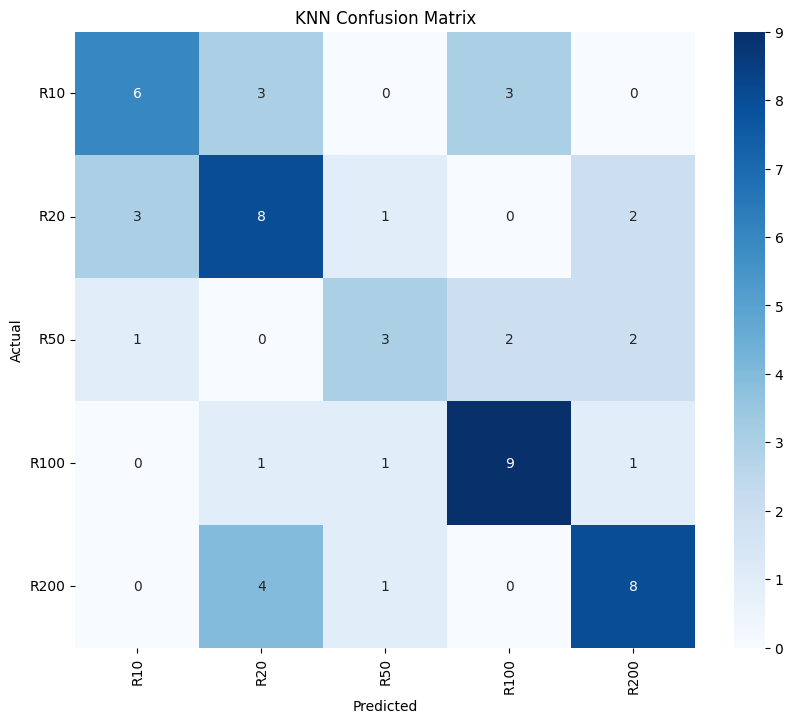

In [ ]:
# KNN Classifier
X_train, X_test, y_train, y_test = load_data()
X_train, X_test = prepare_data(X_train, X_test)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=2, weights='distance', metric='manhattan')

knn.fit(X_train, y_train)

# Predictions
knn_y_pred = knn.predict(X_test)

# Evaluation
evaluate_model("KNN", y_test, knn_y_pred)


SVM  EVALUATION REPORT
 Accuracy: 0.6101694915254238

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.67      0.73        12
           1       0.43      0.71      0.54        14
           2       0.67      0.25      0.36         8
           3       0.73      0.92      0.81        12
           4       0.62      0.38      0.48        13

    accuracy                           0.61        59
   macro avg       0.65      0.59      0.58        59
weighted avg       0.64      0.61      0.60        59


Confusion Matrix:



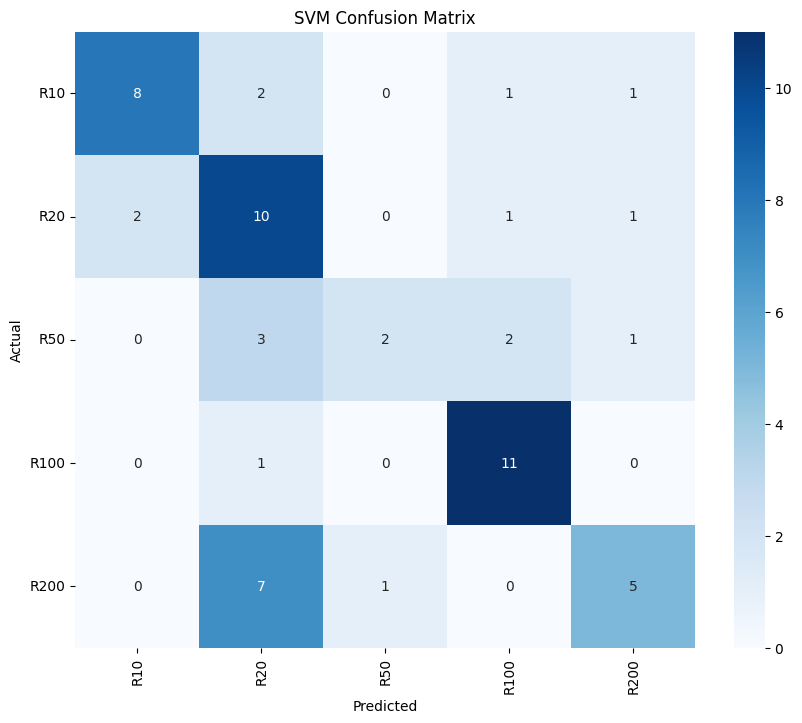

In [ ]:
#SVM model
X_train, X_test, y_train, y_test = load_data()
X_train, X_test = prepare_data(X_train, X_test)

#Train
svm_model = SVC(kernel='rbf',
                C=2,
                gamma = 'scale')

svm_model.fit(X_train, y_train)

#Predictions
svm_y_pred = svm_model.predict(X_test)

# Evaluation
evaluate_model("SVM", y_test, svm_y_pred)